# TELCO CUSTOMER CHURN ANALYSIS

In this project, I am analyzing a telecom company's customer data to understand why customers leave (churn) and what factors affect their decision.

## Questions I want to answer:
- What is the overall churn rate?
- Does gender affect churn?
- Do senior citizens churn more?
- Does contract type affect churn? 
- Does internet service type affect churn?
- Does how long they've been a customer affect churn?
- Which payment method has most churn?

In [1]:
# Importing libraries
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings

warnings.filterwarnings('ignore')

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
# Load the dataset
df = pd.read_csv("data\WA_Fn-UseC_-Telco-Customer-Churn.csv")

print("Dataset loaded successfully!")
print("Total customers:", len(df))
print("Total columns:", len(df.columns))


Dataset loaded successfully!
Total customers: 7043
Total columns: 21


In [3]:
# First look at the data
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [4]:
# Check all column names
print(df.columns.tolist())


['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn']


In [5]:
# Basic info
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


## Understanding the Columns

**Customer Info:**
- gender - Male or Female
- SeniorCitizen - Is the customer a senior citizen? (0 = No, 1 = Yes)
- Partner - Does the customer have a partner?
- Dependents - Does the customer have dependents?

**Account Info:**
- tenure - How many months the customer has been with the company
- Contract - Type of contract (Month-to-month, One year, Two year)
- PaymentMethod - How the customer pays
- MonthlyCharges - How much they pay per month
- TotalCharges - Total amount paid so far

**Services:**
- PhoneService, InternetService, OnlineSecurity, StreamingTV etc.

**Target:**
- Churn - Did the customer leave? (Yes = left, No = stayed) ← this is what we're analyzing

In [6]:
# Check for missing values
print("Missing values:")
print(df.isnull().sum())


Missing values:
customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


## Data Cleaning

I noticed a few things that need to be fixed:
1. TotalCharges column is stored as text - need to convert to number
2. SeniorCitizen is 0/1 - should be Yes/No like other columns
3. customerID column is not useful for analysis - will drop it

In [7]:
# Fix TotalCharges - convert from text to number
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')

# Check how many became missing after conversion
print("Missing in TotalCharges after fix:", df['TotalCharges'].isnull().sum())


Missing in TotalCharges after fix: 11


In [8]:
# Fill those missing TotalCharges with 0
# (these are new customers with 0 tenure so total charge is 0)
df['TotalCharges'].fillna(0, inplace=True)

print("Fixed! Missing values now:",df['TotalCharges'].isnull().sum())

Fixed! Missing values now: 0


In [9]:
# Fix SeniorCitizen - change from 0/1 to No/Yes
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'})
print("SeniorCitizen values now:", df['SeniorCitizen'].unique())


SeniorCitizen values now: ['No' 'Yes']


In [10]:
# Drop customerID - not useful for analysis
df = df.drop('customerID', axis=1)

print("Dropped customerID column")
print("Dataset shape now:", df.shape)


Dropped customerID column
Dataset shape now: (7043, 20)


In [11]:
# Verifying everything looks good
print("Final check - missing values:")
print(df.isnull().sum().sum())

print("\nDataset is clean and ready for analysis!")


Final check - missing values:
0

Dataset is clean and ready for analysis!


---
## Exploratory Data Analysis

Now let's explore the data and find patterns!
---

In [12]:
# Question 1: What is the overall churn rate?
churn_counts = df['Churn'].value_counts()
churn_rate = df['Churn'].value_counts(normalize=True) * 100

print("Churn Counts:")
print(churn_counts)
print("\nChurn Rate:")
print(churn_rate)


Churn Counts:
Churn
No     5174
Yes    1869
Name: count, dtype: int64

Churn Rate:
Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64


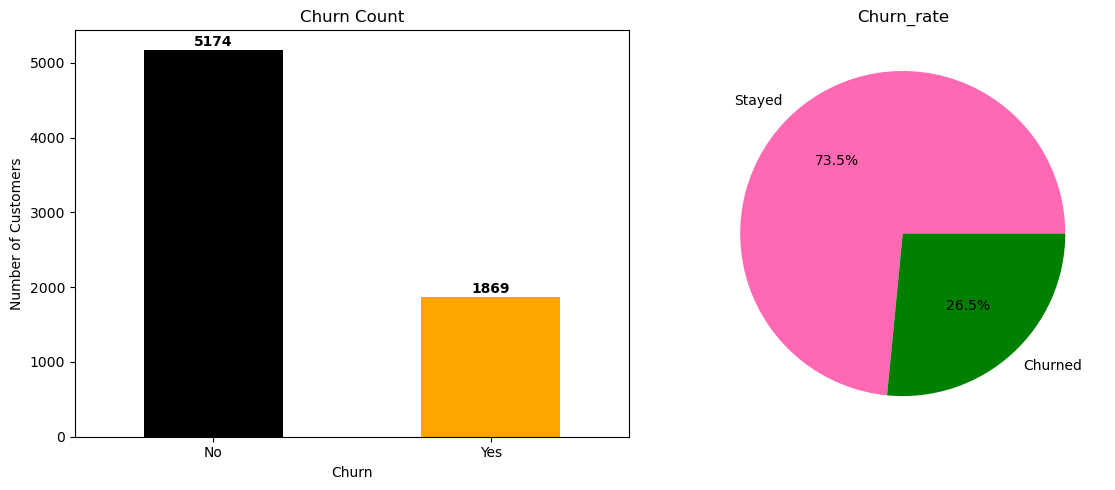

Churn rate: 26.5 %


In [13]:
# Visualize overall churn
fig, axes =  plt.subplots(1, 2, figsize=(12, 5))

# Bar chart
churn_counts.plot(kind='bar', ax=axes[0], color=['black', 'orange'])
axes[0].set_title('Churn Count')
axes[0].set_xlabel('Churn')
axes[0].set_ylabel('Number of Customers')
axes[0].set_xticklabels(['No','Yes'], rotation=0)

for i, v in enumerate(churn_counts):
    axes[0].text(i, v+50, str(v), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(churn_counts, labels=['Stayed', 'Churned'], autopct='%1.1f%%', colors=['hotpink', 'green'])
axes[1].set_title('Churn_rate')

plt.tight_layout()
plt.savefig('images/overall_churn.png')
plt.show()

print("Churn rate:", round(churn_rate['Yes'], 1), "%")


## Observation 1: Churn Rate

About 26.5% of customers have churned.
This means roughly 1 in 4 customers is leaving the company.
This is quite high for a telecom company!

Now let's see WHY they are leaving.

Churn Rate by Gender:
Churn          No        Yes
gender                      
Female  73.079128  26.920872
Male    73.839662  26.160338


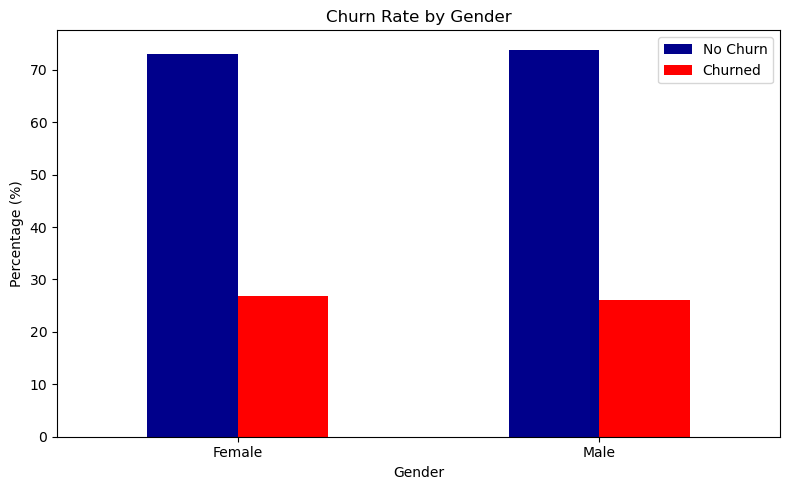

In [14]:
# Question 2: Does gender affect churn?

gender_churn = df.groupby('gender')['Churn'].value_counts(normalize=True).unstack() * 100
print("Churn Rate by Gender:")
print(gender_churn)

# Plot
gender_churn.plot(kind='bar', figsize=(8, 5), color=['darkblue', 'red'])
plt.title('Churn Rate by Gender')
plt.xlabel('Gender')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churned'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/gender_churn.png')
plt.show()


## Observation 2: Gender Doesn't Matter Much

Both males and females churn at almost the same rate (~26%).
Gender is NOT a strong factor in predicting churn.

Churn Rate by Senior Citizen:
Churn                 No        Yes
SeniorCitizen                      
No             76.393832  23.606168
Yes            58.318739  41.681261


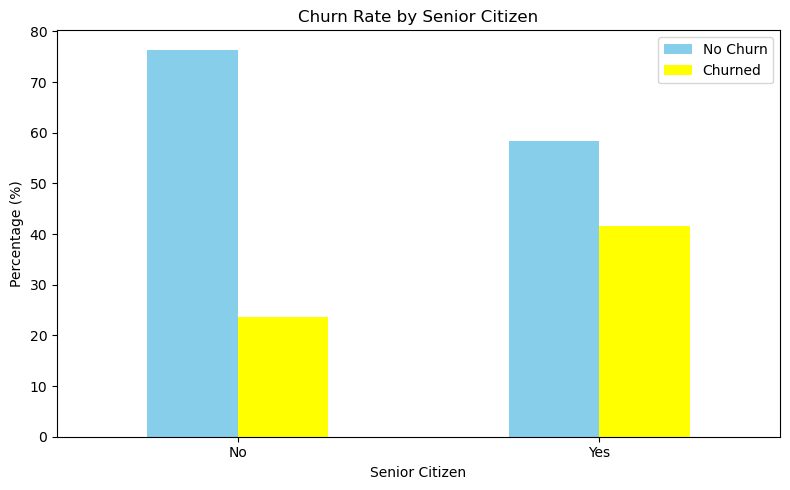

In [15]:
# Question 3: Do senior citizens churn more?

senior_churn = df.groupby('SeniorCitizen')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Senior Citizen:")
print(senior_churn)

# Plot
senior_churn.plot(kind='bar', figsize=(8, 5), color=['skyblue', 'yellow'])
plt.title('Churn Rate by Senior Citizen')
plt.xlabel('Senior Citizen')
plt.ylabel('Percentage (%)')
plt.legend(['No Churn', 'Churned'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('images/senior_churn.png')
plt.show()

## Observation 3: Senior Citizens Churn More!

Senior citizens have a churn rate of ~42%
Non-senior citizens have a churn rate of ~24%

Senior citizens are almost 2x more likely to leave!
This could be because they find the service too complicated or expensive.

Churn Rate by Contract Type:
Churn                  No        Yes
Contract                            
Month-to-month  57.290323  42.709677
One year        88.730482  11.269518
Two year        97.168142   2.831858


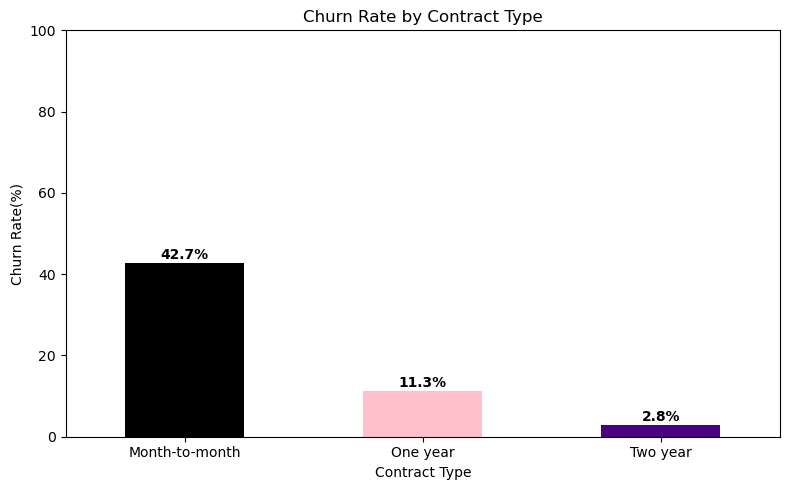

In [16]:
# Question 4: Does contract type affect churn? (Most Important)

contract_churn = df.groupby('Contract')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Contract Type:")
print(contract_churn)

# Plot
contract_churn['Yes'].plot(kind='bar', figsize=(8, 5), color=['black', 'pink', 'indigo'])
plt.title('Churn Rate by Contract Type')
plt.xlabel('Contract Type')
plt.ylabel('Churn Rate(%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, v in enumerate(contract_churn['Yes']):
    plt.text(i, v+1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/contract_churn.png')
plt.show()


## Observation 4: Contract Type is the BIGGEST Factor!

Month-to-month contract: ~43% churn rate.
One year contract: ~11% churn rate.
Two year contract: ~3% churn rate.

Customers on monthly contracts are WAY more likely to leave.
This makes total sense - they have no commitment, so they can leave anytime!

If the company wants to reduce churn, they should try to move customers 
to longer contracts.

Churn Rate by Internet Service:
Churn                   No        Yes
InternetService                      
DSL              81.040892  18.959108
Fiber optic      58.107235  41.892765
No               92.595020   7.404980


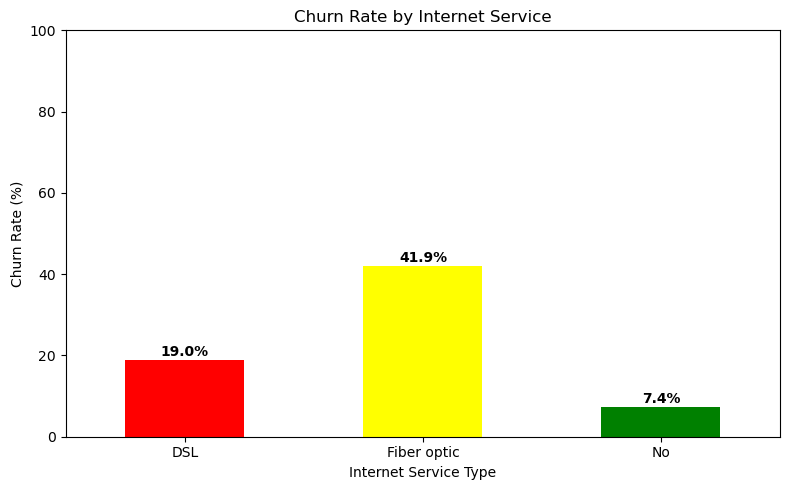

In [17]:
# Question 5: Does internet service type affect churn?

internet_churn = df.groupby('InternetService')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn Rate by Internet Service:")
print(internet_churn)

# Plot
internet_churn['Yes'].plot(kind='bar', figsize=(8, 5), color=['red', 'yellow', 'green'])
plt.title('Churn Rate by Internet Service')
plt.xlabel('Internet Service Type')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=0)
plt.ylim(0, 100)

for i, v in enumerate(internet_churn['Yes']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/internet_churn.png')
plt.show()

## Observation 5: Fiber Optic Customers Churn Most!

DSL internet: ~19% churn rate
Fiber optic: ~42% churn rate
No internet: ~7% churn rate

Fiber optic customers churn the most - probably because:
- It's more expensive
- More competition in fiber optic market
- Customers might find better deals elsewhere

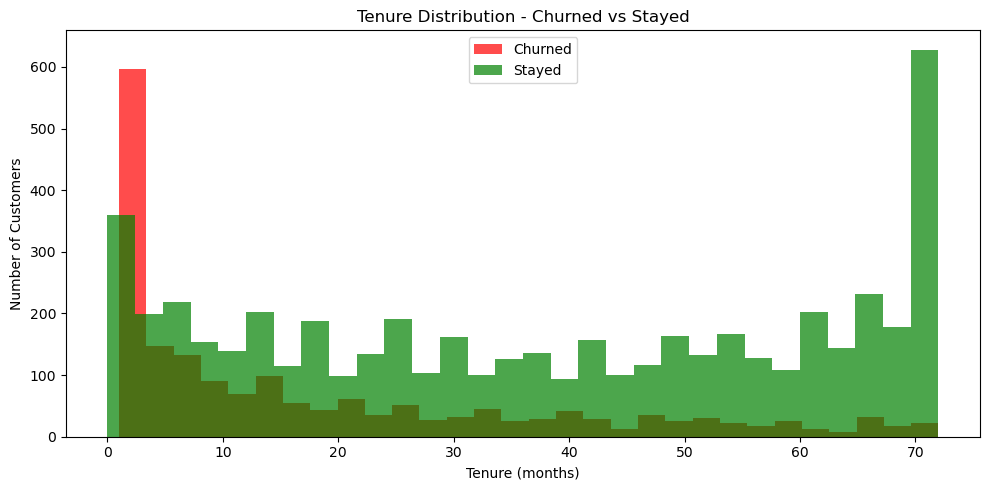

Average tenure of churned customers: 18.0 months
Average tenure of stayed customers: 37.6 months


In [18]:
# Question 6: Does how long they've been a customer affect churn?

plt.figure(figsize=(10, 5))
plt.hist(df[df['Churn']=='Yes']['tenure'], bins=30, alpha=0.7, label='Churned', color='red')
plt.hist(df[df['Churn']=='No']['tenure'], bins=30, alpha=0.7, label='Stayed', color='green')
plt.xlabel('Tenure (months)')
plt.ylabel('Number of Customers')
plt.title('Tenure Distribution - Churned vs Stayed')
plt.legend()
plt.tight_layout()
plt.savefig('images/tenure_churn.png')
plt.show()

print("Average tenure of churned customers:", round(df[df['Churn']=='Yes']['tenure'].mean(), 1), "months")
print("Average tenure of stayed customers:", round(df[df['Churn']=='No']['tenure'].mean(), 1), "months")

## Observation 6: New Customers Churn the Most!

Average tenure of churned customers: ~18 months
Average tenure of stayed customers: ~38 months

New customers (low tenure) are much more likely to churn.
Once a customer stays for 2-3 years, they rarely leave.

This means the company needs to focus on keeping NEW customers happy!

Churn by Payment Method:
PaymentMethod
Bank transfer (automatic)    16.709845
Credit card (automatic)      15.243101
Electronic check             45.285412
Mailed check                 19.106700
Name: Yes, dtype: float64


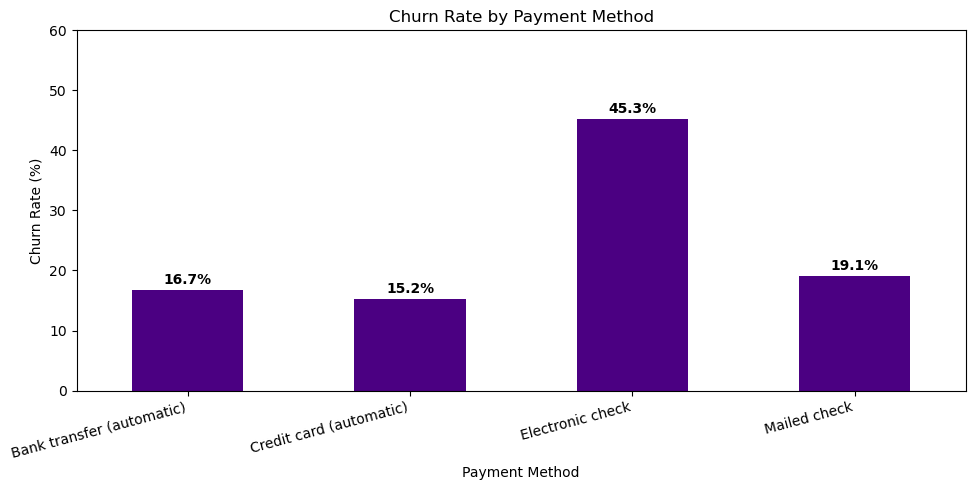

In [19]:
# Question 7: Which payment method has most churn?

payment_churn = df.groupby('PaymentMethod')['Churn'].value_counts(normalize=True).unstack() * 100

print("Churn by Payment Method:")
print(payment_churn['Yes'])

# Plot
payment_churn['Yes'].plot(kind='bar', figsize=(10, 5), color='indigo')
plt.title('Churn Rate by Payment Method')
plt.xlabel('Payment Method')
plt.ylabel('Churn Rate (%)')
plt.xticks(rotation=15, ha='right')
plt.ylim(0, 60)

for i, v in enumerate(payment_churn['Yes']):
    plt.text(i, v + 1, f'{v:.1f}%', ha='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/payment_churn.png')
plt.show()

## Observation 7: Electronic Check Users Churn Most!

Electronic check: ~45% churn rate
Mailed check: ~19%
Bank transfer: ~17%
Credit card: ~15%

Electronic check users churn the most.
Automatic payment methods (bank transfer, credit card) have much lower churn.
Maybe automatic payments make it easier to stay - customers don't actively think about their bill.

                       Factor  Churn Rate (%)
0                     Overall            26.5
1              Senior Citizen            41.7
2     Month-to-Month Contract            42.7
3        Fiber Optic Internet            41.9
4  New Customer (0-12 months)            47.4
5    Electronic Check Payment            45.3


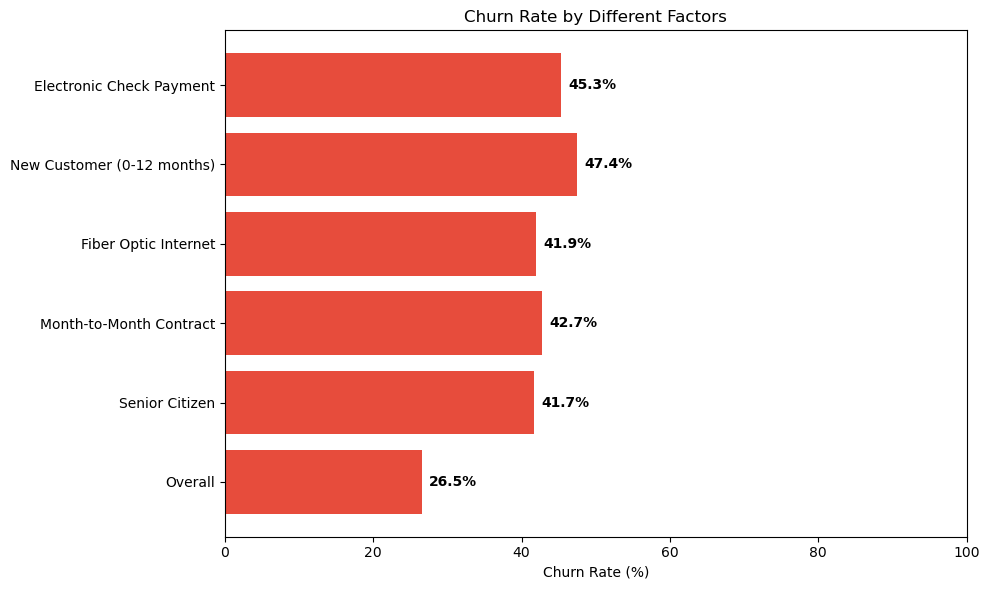

In [20]:
# Final Summary - all churn rates together

summary = {
    'Factor': ['Overall', 'Senior Citizen', 'Month-to-Month Contract', 
               'Fiber Optic Internet', 'New Customer (0-12 months)', 
               'Electronic Check Payment'],
    'Churn Rate (%)': [
        round(df['Churn'].value_counts(normalize=True)['Yes'] * 100, 1),
        round(df[df['SeniorCitizen']=='Yes']['Churn'].value_counts(normalize=True)['Yes'] * 100, 1),
        round(df[df['Contract']=='Month-to-month']['Churn'].value_counts(normalize=True)['Yes'] * 100, 1),
        round(df[df['InternetService']=='Fiber optic']['Churn'].value_counts(normalize=True)['Yes'] * 100, 1),
        round(df[df['tenure']<=12]['Churn'].value_counts(normalize=True)['Yes'] * 100, 1),
        round(df[df['PaymentMethod']=='Electronic check']['Churn'].value_counts(normalize=True)['Yes'] * 100, 1)
    ]
}

summary_df = pd.DataFrame(summary)
print(summary_df)

# Plot summary
plt.figure(figsize=(10, 6))
plt.barh(summary_df['Factor'], summary_df['Churn Rate (%)'], color='#e74c3c')
plt.xlabel('Churn Rate (%)')
plt.title('Churn Rate by Different Factors')
plt.xlim(0, 100)

for i, v in enumerate(summary_df['Churn Rate (%)']):
    plt.text(v + 1, i, f'{v}%', va='center', fontweight='bold')

plt.tight_layout()
plt.savefig('images/summary_churn.png')
plt.show()

---
# Final Summary & Key Findings

## What I Found:

1. **Overall churn rate is 26.5%** - 1 in 4 customers is leaving

2. **Contract type is the biggest factor**
   - Month-to-month: 43% churn
   - Two year contract: only 3% churn

3. **New customers are most at risk**
   - Customers in first year churn the most
   - Long-term customers rarely leave

4. **Fiber optic users churn more** (~42%)
   - Probably due to higher cost and more competition

5. **Senior citizens churn more** (~42%)
   - Almost 2x more than non-seniors

6. **Electronic check users churn most** (~45%)
   - Automatic payment users are more loyal

7. **Gender doesn't matter**
   - Males and females churn at same rate

## Business Recommendations:

- Push customers towards longer contracts
- Focus on keeping NEW customers happy in first year
- Look into why fiber optic customers are unhappy
- Encourage automatic payment methods
- Create special plans for senior citizens

## What I Learned:

- Real business datasets are messier than Titanic (TotalCharges was stored as text!)
- Not all factors matter equally (gender didn't matter at all)
- EDA helps companies make real decisions
- Groupby and value_counts are super useful for categorical analysis

---

## Tools Used:
- Python
- Pandas
- Matplotlib
- Seaborn
- Jupyter Notebook

## Dataset Source:
IBM Sample Dataset - Telco Customer Churn (from Kaggle)

---

**This was my EDA project. I'm learning how to find business insights from data!**

**Contact:**
- GitHub: [@shubhamjais04](https://github.com/shubhamjais04)
- LinkedIn: [linkedin.com/in/shubhamjaiswal2004](https://linkedin.com/in/shubhamjaiswal2004)